In [14]:
import sys
!{sys.executable} -m pip install requests

In [16]:
import os

print(os.path.exists("fruits.zip"))
print(os.path.getsize("fruits.zip"))

True
105946856


In [17]:
import zipfile

with zipfile.ZipFile("fruits.zip", "r") as zip_ref:
    zip_ref.extractall("fruits")

print("Extraction completed!")

Extraction completed!


In [18]:
import os

print(os.listdir("fruits"))

['fruits', '__MACOSX']


In [8]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [9]:
tf.__version__

'2.21.0'

In [23]:
img_height, img_width = 32, 32
batch_size=20

train_ds = tf.keras.utils.image_dataset_from_directory(
    "fruits/fruits/train",
    image_size = (img_height, img_width),
    batch_size = batch_size
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    "fruits/fruits/validation",
    image_size = (img_height, img_width),
    batch_size = batch_size
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    "fruits/fruits/test",
    image_size = (img_height, img_width),
    batch_size = batch_size
)

Found 460 files belonging to 3 classes.


Found 66 files belonging to 3 classes.
Found 130 files belonging to 3 classes.


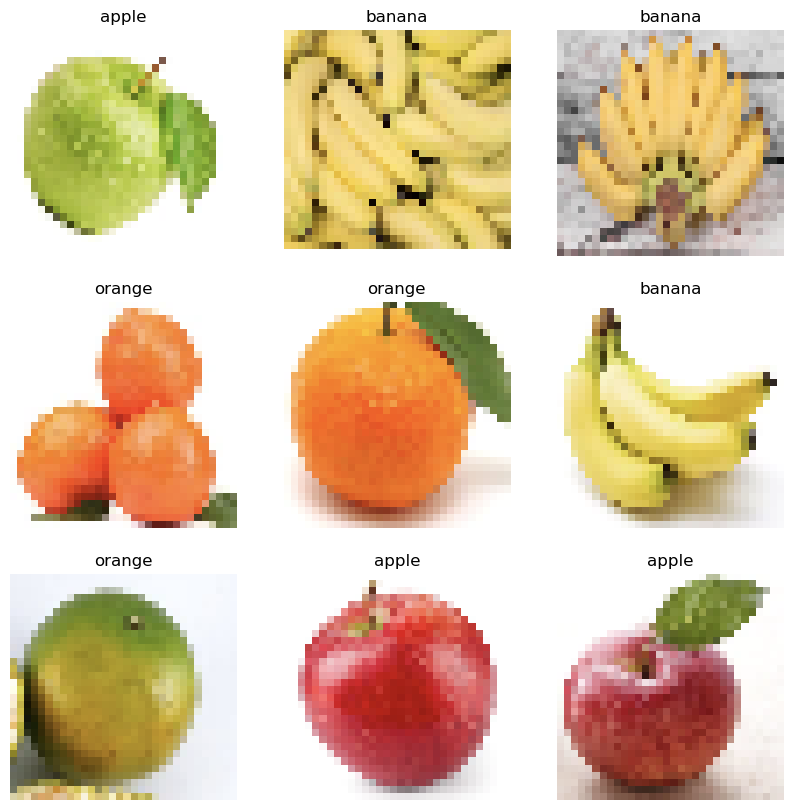

In [24]:
class_names = ['apple','banana','orange']
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")


In [25]:
model = tf.keras.Sequential(
    [
        tf.keras.layers.Rescaling(1./255),
        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(128, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='softmax'),
        tf.keras.layers.Dense(3)
    ]
)

In [26]:
model.compile(
    optimizer='rmsprop',
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [27]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - accuracy: 0.3391 - loss: 1.0984 - val_accuracy: 0.3485 - val_loss: 1.0974
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.3826 - loss: 1.0953 - val_accuracy: 0.3333 - val_loss: 1.0800
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.4283 - loss: 1.0712 - val_accuracy: 0.5758 - val_loss: 1.0331
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.5543 - loss: 1.0189 - val_accuracy: 0.5909 - val_loss: 0.9732
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5891 - loss: 0.9831 - val_accuracy: 0.4394 - val_loss: 0.9911
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.6913 - loss: 0.9593 - val_accuracy: 0.7576 - val_loss: 0.9413
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.7196 - loss: 0.9407 - val_accuracy: 0.7727 - val_loss: 0.9112
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.7652 - loss: 0.9052 - val_accuracy: 0.7879 - 

In [28]:
model.evaluate(test_ds)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.9615 - loss: 0.5892


[0.5891876816749573, 0.9615384340286255]

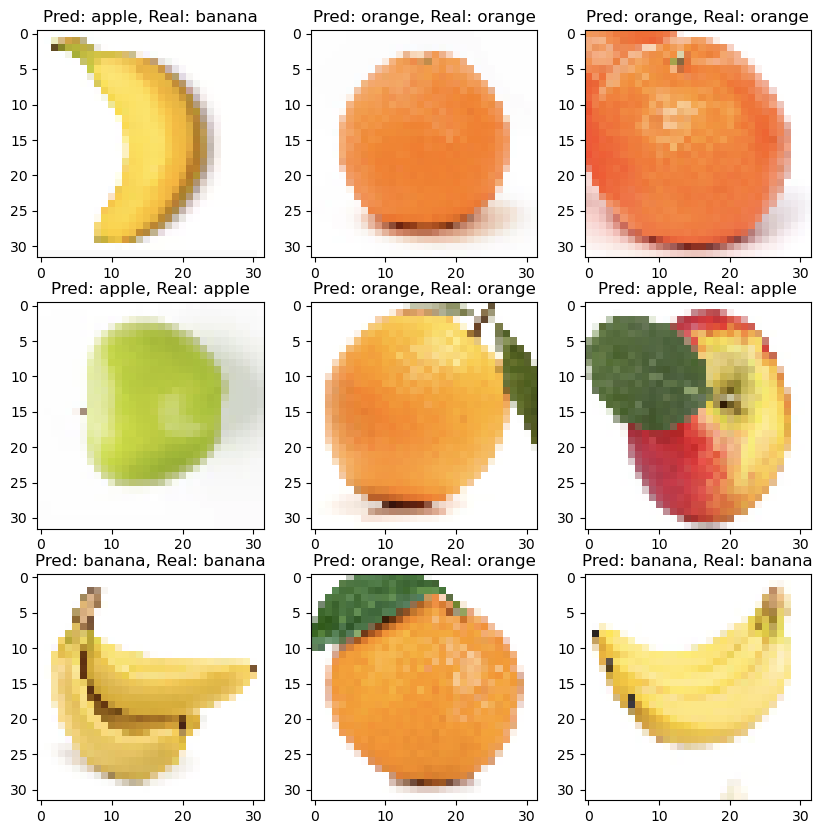

In [29]:
import numpy as np

plt.figure(figsize=(10, 10))
for images,labels in test_ds.take(1):
  classifications= model(images)


  for i in range(9):
    ax=plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    index=np.argmax(classifications[i])
    plt.title("Pred: "+class_names[index]+", Real: "+class_names[labels[i]])

In [30]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("model.tflite", 'wb') as f:
  f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\beher\AppData\Local\Temp\tmpym1mv4k8\assets


INFO:tensorflow:Assets written to: C:\Users\beher\AppData\Local\Temp\tmpym1mv4k8\assets


Saved artifact at 'C:\Users\beher\AppData\Local\Temp\tmpym1mv4k8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1584143343184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1584143342800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1584143345680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1584143347024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1584143342992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1584143347600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1584143068688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1584143068496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1584143067152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1584143063120: TensorSpec(shape=(), dtype=tf.resource, name=None)
